# Проект: Модель МО для выбора коров ЭкоФерма

Цель проекта: Разработать модель машинного обучения, которая поможет управлять рисками и принимать объективное решение о покупке.
Для этого мы выполним следующие шаги:
1. Загрузим и изучим данные.
2. Проведём их предобработку.
3. Сделаем исследовательский анализ данных.
4. Обучим модели линейной регрессии.
5. Обучим модели классификации.
6. Сделаем итоговые выводы.

## Загрузка и изучение данных

Цель: Импортируем библиотеки, загрузим три датасета, первично изучим данные.

### Импорт библиотек

In [1]:
!pip install phik -q
!pip install scikit-learn -U -q

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score
)

### Загрузка датасетов

In [3]:
ferma_main = pd.read_csv("/datasets/ferma_main.csv", sep = ';')
ferma_dad = pd.read_csv("/datasets/ferma_dad.csv", sep = ';')
cow_buy = pd.read_csv("/datasets/cow_buy.csv", sep = ';')

Дата сеты загружены и записаны в переменные.

### Структура и общая информация о дата сетах

In [4]:
ferma_main.head(5)

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


Приведём названия столбцов к более унифицированной форме

In [5]:
ferma_main = ferma_main.rename(columns={'Удой, кг': 'milk_kg',
                                        'ЭКЕ (Энергетическая кормовая единица)': 'feed_energy_unit',
                                        'Сырой протеин, г': 'crude_protein_g',
                                        'СПО (Сахаро-протеиновое соотношение)': 'sugar_protein_ratio',
                                        'Порода': 'breed',
                                        'Тип пастбища': 'pasture_type',
                                        'порода папы_быка': 'breed_of_daddy_bull',
                                        'Жирность,%':'fat_content_percent',
                                        'Белок,%': 'protein_percent',
                                        'Вкус молока': 'taste_of_milk',
                                        'Возраст': 'age'})

In [6]:
ferma_main.head(5)

,id,milk_kg,feed_energy_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,breed_of_daddy_bull,fat_content_percent,protein_percent,taste_of_milk,age
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [7]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   634 non-null    int64 
 1   milk_kg              634 non-null    int64 
 2   feed_energy_unit     634 non-null    object
 3   crude_protein_g      634 non-null    int64 
 4   sugar_protein_ratio  634 non-null    object
 5   breed                634 non-null    object
 6   pasture_type         634 non-null    object
 7   breed_of_daddy_bull  634 non-null    object
 8   fat_content_percent  634 non-null    object
 9   protein_percent      634 non-null    object
 10  taste_of_milk        634 non-null    object
 11  age                  634 non-null    object
dtypes: int64(3), object(9)
memory usage: 59.6+ KB


In [8]:
ferma_dad.head(5)

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [9]:
ferma_dad = ferma_dad.rename(columns={'Имя Папы': 'dad_name'})

In [10]:
ferma_dad.head(5)

,id,dad_name
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [11]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   dad_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [12]:
cow_buy.head(5)

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [13]:
cow_buy = cow_buy.rename(columns={'Порода': 'breed',
                                  'Тип пастбища': 'pasture_type',
                                  'порода папы_быка': 'breed_of_daddy_bull',
                                  'Имя_папы': 'dad_name',
                                  'Текущая_жирность,%': 'fat_content_percent',
                                  'Текущий_уровень_белок,%': 'current_protein_level_percent',
                                  'Возраст': 'age'})

In [14]:
cow_buy.head(5)

,breed,pasture_type,breed_of_daddy_bull,dad_name,fat_content_percent,current_protein_level_percent,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [15]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   breed                          20 non-null     object
 1   pasture_type                   20 non-null     object
 2   breed_of_daddy_bull            20 non-null     object
 3   dad_name                       20 non-null     object
 4   fat_content_percent            20 non-null     object
 5   current_protein_level_percent  20 non-null     object
 6   age                            20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


Вывод: Импортировали библиотеки, загрузили датафреймы, привели названия к универсальному виду.

## Предобработка данных

Цель: Проверить данные на дубликаты, проверим типы данных.

### Проверка данных на пропуски

In [16]:
miss_value_ferma_main = ferma_main.isnull().sum()
print(miss_value_ferma_main[miss_value_ferma_main > 0])

Series([], dtype: int64)


In [17]:
miss_value_ferma_dad = ferma_dad.isnull().sum()
print(miss_value_ferma_dad[miss_value_ferma_dad > 0])

Series([], dtype: int64)


In [18]:
miss_value_cow_buy = cow_buy.isnull().sum()
print(miss_value_cow_buy[miss_value_cow_buy > 0])

Series([], dtype: int64)


Пропусков в данных нет.

### Проверка данных на дубликаты

In [19]:
print(f'В таблице ferma_main явных дубликатов: ', ferma_main.duplicated().sum())
print(f'В таблице ferma_dad явных дубликатов: ', ferma_dad.duplicated().sum())
print(f'В таблице cow_buy явных дубликатов: ', cow_buy.duplicated().sum())

В таблице ferma_main явных дубликатов:  5
В таблице ferma_dad явных дубликатов:  0
В таблице cow_buy явных дубликатов:  4


In [20]:
duplicates_ferma_main = ferma_main[ferma_main.duplicated()]
duplicates_ferma_main

,id,milk_kg,feed_energy_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,breed_of_daddy_bull,fat_content_percent,protein_percent,taste_of_milk,age
629,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
630,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
631,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
632,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
633,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет


In [21]:
duplicates_cow_buy = cow_buy[cow_buy.duplicated()]
duplicates_cow_buy

,breed,pasture_type,breed_of_daddy_bull,dad_name,fat_content_percent,current_protein_level_percent,age
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
14,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
19,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [22]:
ferma_main = ferma_main.drop_duplicates()
#cow_buy = cow_buy.drop_duplicates()

In [23]:
print(f'В таблице ferma_main явных дубликатов: ', ferma_main.duplicated().sum())
print(f'В таблице cow_buy явных дубликатов: ', cow_buy.duplicated().sum())

В таблице ferma_main явных дубликатов:  0
В таблице cow_buy явных дубликатов:  4


Явные дубликаты в датасете ferma_main удалены, дубликаты в cow_buy оставим для дальнейшего исследования.

Проверим на неявные дубликаты

In [24]:
print(ferma_main['breed'].unique())

['Вис Бик Айдиал' 'РефлешнСоверинг']


In [25]:
print(ferma_main['pasture_type'].unique())

['Равнинное' 'Равнинные' 'Холмистое']


In [26]:
print(ferma_main['breed_of_daddy_bull'].unique())

['Айдиал' 'Соверин' 'Айдиалл']


In [27]:
print(ferma_main['taste_of_milk'].unique())

['вкусно' 'не вкусно']


In [28]:
print(ferma_main['age'].unique())

['более_2_лет' 'менее_2_лет']


В столбцах pasture_type и breed_of_daddy_bull присутствуют неявные дубликаты. Исправим это.

In [29]:
ferma_main['pasture_type'] = ferma_main['pasture_type'].replace({'Равнинные':'Равнинное'})
ferma_main['breed_of_daddy_bull'] = ferma_main['breed_of_daddy_bull'].replace({'Айдиалл':'Айдиал'})

In [30]:
print(ferma_main['pasture_type'].unique())

['Равнинное' 'Холмистое']


In [31]:
print(ferma_main['breed_of_daddy_bull'].unique())

['Айдиал' 'Соверин']


Поправили неявные дубликаты в датафрейме ferma_main. Проверим другие датафреймы.

In [32]:
print(ferma_dad['dad_name'].unique())

['Буйный' 'Соловчик' 'Барин' 'Геркулес']


В датафрейме ferma_dad неявных дубликатов нет.

In [33]:
print(cow_buy['breed'].unique())

['Вис Бик Айдиал' 'РефлешнСоверинг']


In [34]:
print(cow_buy['breed_of_daddy_bull'].unique())

['Айдиал' 'Соверин']


In [35]:
print(cow_buy['dad_name'].unique())

['Геркулес' 'Буйный' 'Барин' 'Соловчик']


In [36]:
print(cow_buy['pasture_type'].unique())

['холмистое' 'равнинное']


In [37]:
print(cow_buy['age'].unique())

['более_2_лет' 'менее_2_лет']


Датафреймы проверены на неявные дуюликаты и очищены.

### Проверка типов данных

In [38]:
ferma_main.head(5)

,id,milk_kg,feed_energy_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,breed_of_daddy_bull,fat_content_percent,protein_percent,taste_of_milk,age
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинное,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинное,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [39]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   629 non-null    int64 
 1   milk_kg              629 non-null    int64 
 2   feed_energy_unit     629 non-null    object
 3   crude_protein_g      629 non-null    int64 
 4   sugar_protein_ratio  629 non-null    object
 5   breed                629 non-null    object
 6   pasture_type         629 non-null    object
 7   breed_of_daddy_bull  629 non-null    object
 8   fat_content_percent  629 non-null    object
 9   protein_percent      629 non-null    object
 10  taste_of_milk        629 non-null    object
 11  age                  629 non-null    object
dtypes: int64(3), object(9)
memory usage: 63.9+ KB


In [40]:
ferma_main['feed_energy_unit'] = ferma_main['feed_energy_unit'].str.replace(',','.', regex = False).astype(float)

In [41]:
ferma_main['sugar_protein_ratio'] = ferma_main['sugar_protein_ratio'].str.replace(',','.', regex = False).astype(float)

In [42]:
ferma_main['fat_content_percent'] = ferma_main['fat_content_percent'].str.replace(',','.', regex = False).astype(float)

In [43]:
ferma_main['protein_percent'] = ferma_main['protein_percent'].str.replace(',','.', regex = False).astype(float)

In [44]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   629 non-null    int64  
 1   milk_kg              629 non-null    int64  
 2   feed_energy_unit     629 non-null    float64
 3   crude_protein_g      629 non-null    int64  
 4   sugar_protein_ratio  629 non-null    float64
 5   breed                629 non-null    object 
 6   pasture_type         629 non-null    object 
 7   breed_of_daddy_bull  629 non-null    object 
 8   fat_content_percent  629 non-null    float64
 9   protein_percent      629 non-null    float64
 10  taste_of_milk        629 non-null    object 
 11  age                  629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.9+ KB


In [45]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   dad_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [46]:
cow_buy.head(5)

,breed,pasture_type,breed_of_daddy_bull,dad_name,fat_content_percent,current_protein_level_percent,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [47]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   breed                          20 non-null     object
 1   pasture_type                   20 non-null     object
 2   breed_of_daddy_bull            20 non-null     object
 3   dad_name                       20 non-null     object
 4   fat_content_percent            20 non-null     object
 5   current_protein_level_percent  20 non-null     object
 6   age                            20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


In [48]:
cow_buy['fat_content_percent'] = cow_buy['fat_content_percent'].str.replace(',','.', regex = False).astype(float)

In [49]:
cow_buy['current_protein_level_percent'] = cow_buy['current_protein_level_percent'].str.replace(',','.', regex = False).astype(float)

In [50]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   breed                          20 non-null     object 
 1   pasture_type                   20 non-null     object 
 2   breed_of_daddy_bull            20 non-null     object 
 3   dad_name                       20 non-null     object 
 4   fat_content_percent            20 non-null     float64
 5   current_protein_level_percent  20 non-null     float64
 6   age                            20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


Изменили типы данных на более корректные.

Вывод: проверили данные на явные и не явные дубликаты, разобрались с ними. Провели данные на пропуски. Привели стобцы к верному типу данных.

## Исследовательский анализ данных

Цель: Проведём исследовательский анализ данных, проведем статистический анализ, после чего проведём корреляционный анализ признаков в датасете ferma_main.

Создадим несколько функций, которые позволят упростить однотипные дейтсвия.

In [51]:
def plot_boxplot(df, column, title = None, figsize=(6,4)):
    plt.figure(figsize=figsize)
    df.boxplot(column=column)
    plt.title(title)
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

In [52]:
def plot_distr(df, column, bins = 30, kde = True, figsize = (8,5), title = None):
    plt.figure(figsize=figsize)
    sns.histplot(df[column], bins=bins, kde = kde, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.grid(True)
    plt.show()

In [53]:
def plot_value_counts(df, column, figsize=(8,5), title = None):
    value_counts=df[column].value_counts()
    plt.figure(figsize=figsize)
    value_counts.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.title(title or f'Частота значений {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.grid(axis='y')
    plt.show()

### Исследуем дата сет ferma_main

Начнём с датасета ferma_main, исследуем все его количественные признаки.

In [54]:
ferma_main.shape

(629, 12)

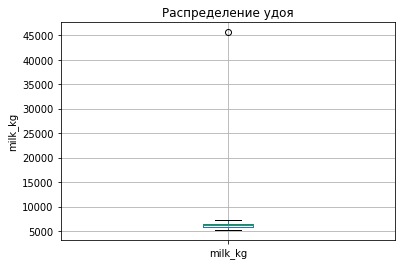

In [55]:
plot_boxplot(ferma_main, 'milk_kg', title = 'Распределение удоя')

In [56]:
ferma_main['milk_kg'].median()

6133.0

In [57]:
ferma_main['milk_kg'].max()

45616

In [58]:
ferma_main.loc[ferma_main['milk_kg'] == ferma_main['milk_kg'].max()]

,id,milk_kg,feed_energy_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,breed_of_daddy_bull,fat_content_percent,protein_percent,taste_of_milk,age
16,17,45616,11.5,1675,0.93,Вис Бик Айдиал,Холмистое,Айдиал,3.22,3.076,вкусно,более_2_лет


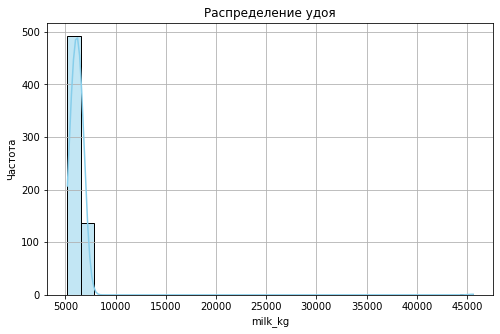

In [59]:
plot_distr(ferma_main, 'milk_kg', title = 'Распределение удоя')

Виден выброс у коровы с id 17.

In [60]:
ferma_main_cleaned = ferma_main[ferma_main['milk_kg'] != 45616]

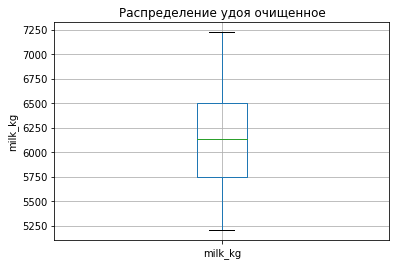

In [61]:
plot_boxplot(ferma_main_cleaned, 'milk_kg', title = 'Распределение удоя очищенное')

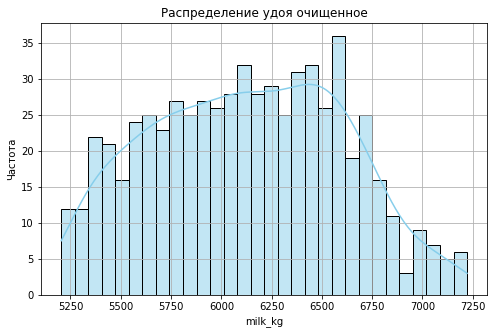

In [62]:
plot_distr(ferma_main_cleaned, 'milk_kg', title = 'Распределение удоя очищенное')

Убрали выброс, проверили как выглядит распределение. Оно близко к нормальному.

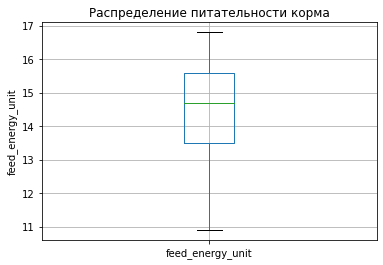

In [63]:
plot_boxplot(ferma_main, 'feed_energy_unit', title = 'Распределение питательности корма')

Выбросов нет

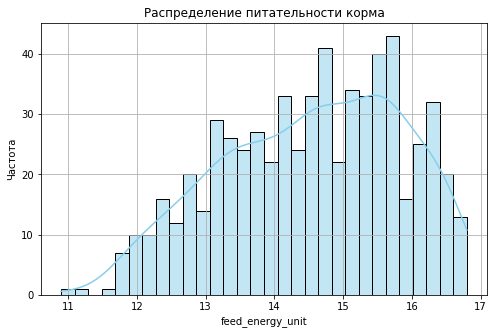

In [64]:
plot_distr(ferma_main, 'feed_energy_unit', title = 'Распределение питательности корма')

Распределение близко к нормальному.

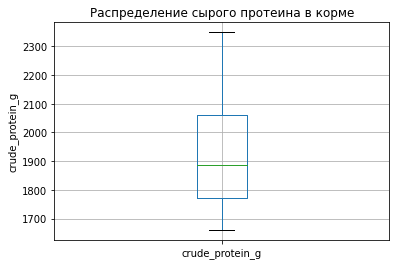

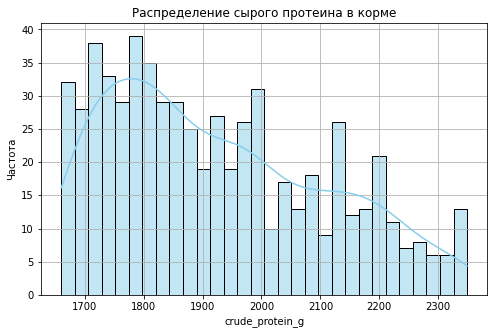

In [65]:
plot_boxplot(ferma_main, 'crude_protein_g', title = 'Распределение сырого протеина в корме')
plot_distr(ferma_main, 'crude_protein_g', title = 'Распределение сырого протеина в корме')

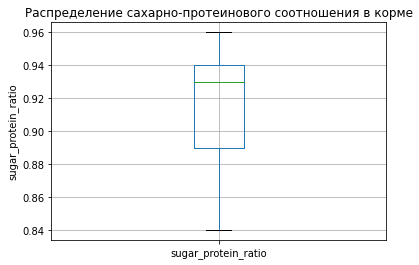

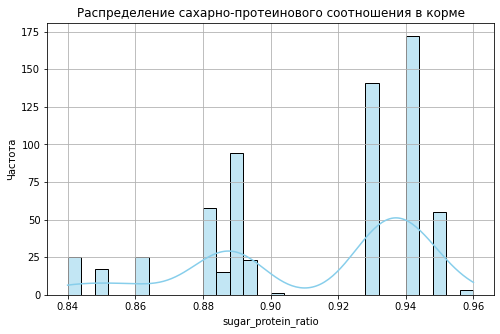

In [66]:
plot_boxplot(ferma_main, 'sugar_protein_ratio', title = 'Распределение сахарно-протеинового соотношения в корме')
plot_distr(ferma_main, 'sugar_protein_ratio', title = 'Распределение сахарно-протеинового соотношения в корме')

Распределение в этом случае бимодальное.

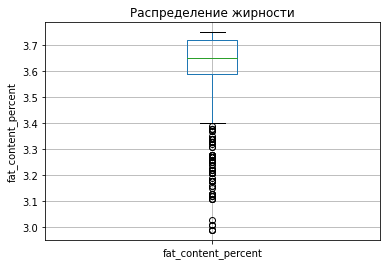

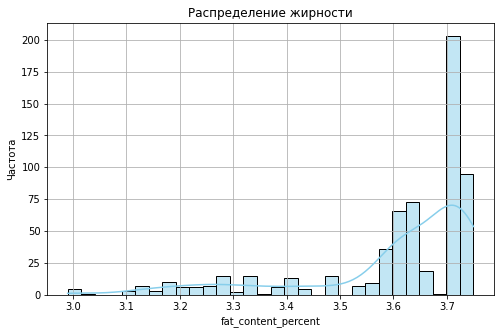

In [67]:
plot_boxplot(ferma_main, 'fat_content_percent', title = 'Распределение жирности')
plot_distr(ferma_main, 'fat_content_percent', title = 'Распределение жирности')

Обратим внимание, что у некоторых коров пониженная жирность молока, они дают выбросы.

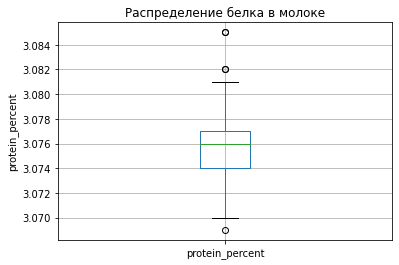

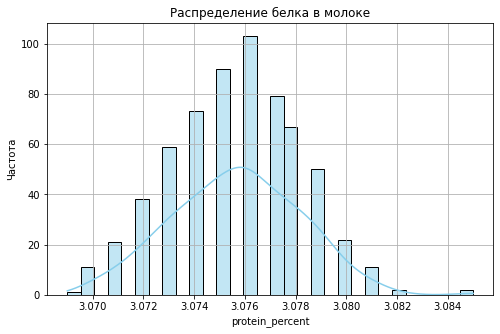

In [68]:
plot_boxplot(ferma_main, 'protein_percent', title = 'Распределение белка в молоке')
plot_distr(ferma_main, 'protein_percent', title = 'Распределение белка в молоке')

В данных есть несколько выбросов.

Теперь рассмотрим категроиальные признаки:

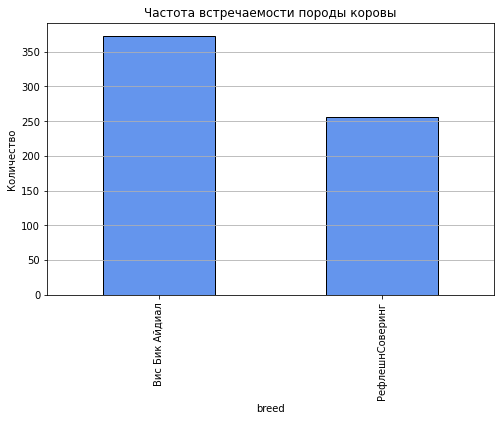

In [69]:
plot_value_counts(ferma_main, 'breed', title = 'Частота встречаемости породы коровы')

In [70]:
count_target = len(ferma_main[ferma_main['breed'] == 'Вис Бик Айдиал'])
count_others = len(ferma_main[ferma_main['breed'] != 'Вис Бик Айдиал'])

print(f'Коровы с породой "Вис Бик Айдиал" встречаются на {count_target - count_others} раз чаще')


Коровы с породой "Вис Бик Айдиал" встречаются на 117 раз чаще


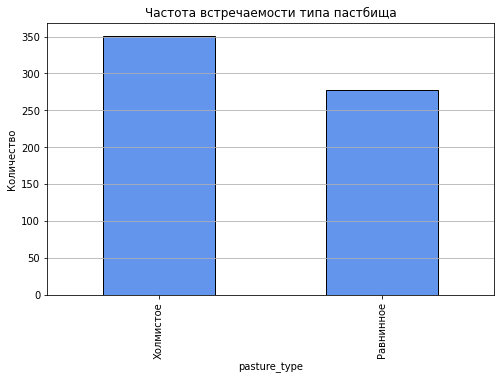

In [71]:
plot_value_counts(ferma_main, 'pasture_type', title = 'Частота встречаемости типа пастбища')

In [72]:
count_target_pasture = len(ferma_main[ferma_main['pasture_type'] == 'Холмистое'])
count_others_pasture = len(ferma_main[ferma_main['pasture_type'] != 'Холмистое'])

print(f'Коровы с породой "Холмистое" встречаются на {count_target - count_others} раз чаще')


Коровы с породой "Холмистое" встречаются на 117 раз чаще


Можно предположить, что определённая порода пасётся только на определённом типе пастбищ. Проверим.

In [73]:
ferma_main_vis_aidal = ferma_main[ferma_main['breed'] == 'Вис Бик Айдиал']
ferma_main_vis_aidal['pasture_type'].unique()

array(['Равнинное', 'Холмистое'], dtype=object)

In [74]:
ferma_main_not_vis_aidal = ferma_main[ferma_main['breed'] != 'Вис Бик Айдиал']
ferma_main_not_vis_aidal['pasture_type'].unique()

array(['Холмистое', 'Равнинное'], dtype=object)

In [75]:
ferma_main

,id,milk_kg,feed_energy_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,breed_of_daddy_bull,fat_content_percent,protein_percent,taste_of_milk,age
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
624,625,6812,15.4,1964,0.940,РефлешнСоверинг,Равнинное,Айдиал,3.74,3.075,не вкусно,более_2_лет
625,626,5513,12.9,1700,0.880,РефлешнСоверинг,Равнинное,Соверин,3.64,3.073,вкусно,менее_2_лет
626,627,5970,14.4,1837,0.880,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
627,628,5746,13.8,1994,0.890,РефлешнСоверинг,Равнинное,Соверин,3.64,3.077,вкусно,более_2_лет


Проверили, теория не подтвердилась.

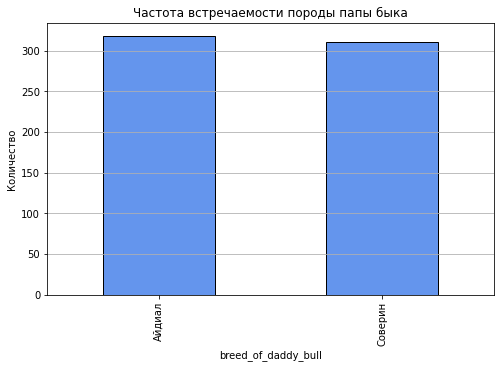

In [76]:
plot_value_counts(ferma_main, 'breed_of_daddy_bull', title = 'Частота встречаемости породы папы быка')

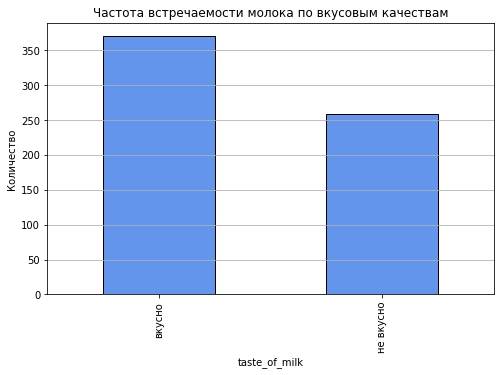

In [77]:
plot_value_counts(ferma_main, 'taste_of_milk', title = 'Частота встречаемости молока по вкусовым качествам')

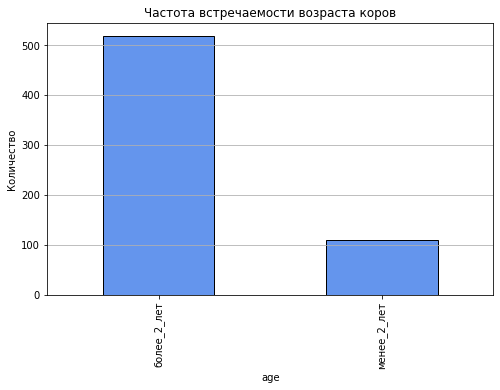

In [78]:
plot_value_counts(ferma_main, 'age', title = 'Частота встречаемости возраста коров')

### Исследуем дата сет ferma_dad

In [79]:
ferma_dad.shape

(629, 2)

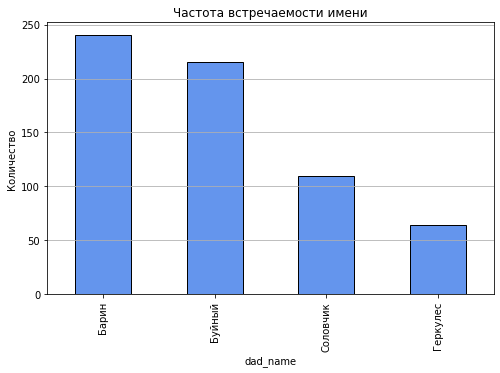

In [80]:
plot_value_counts(ferma_dad, 'dad_name', title = 'Частота встречаемости имени')

### Исследуем дата сет cow_buy

In [81]:
cow_buy.shape

(20, 7)

Исследуем количественные признаки.

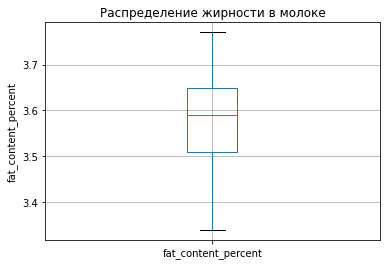

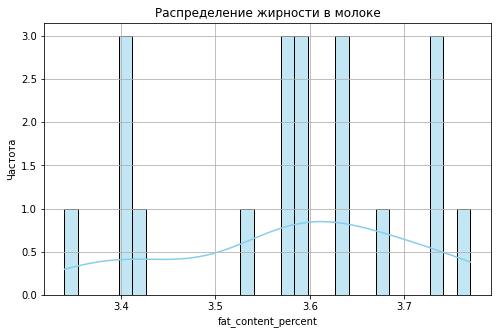

In [82]:
plot_boxplot(cow_buy, 'fat_content_percent', title = 'Распределение жирности в молоке')
plot_distr(cow_buy, 'fat_content_percent', title = 'Распределение жирности в молоке')

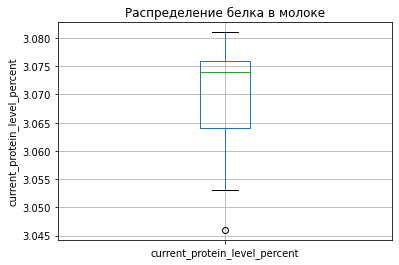

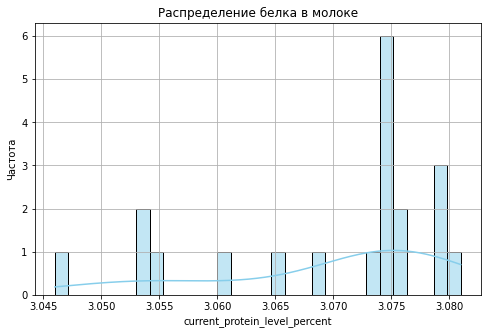

In [83]:
plot_boxplot(cow_buy, 'current_protein_level_percent', title = 'Распределение белка в молоке')
plot_distr(cow_buy, 'current_protein_level_percent', title = 'Распределение белка в молоке')

Теперь исследуем категориальные признаки.

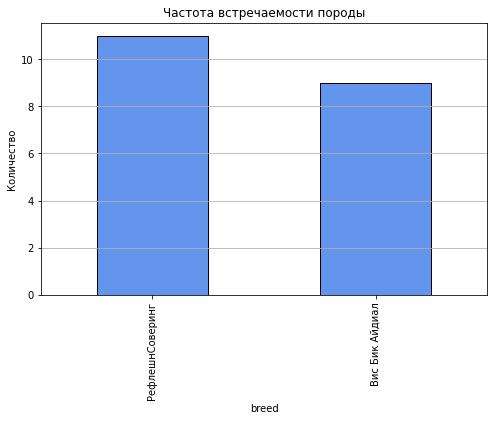

In [84]:
plot_value_counts(cow_buy, 'breed', title = 'Частота встречаемости породы')

Частота встречаесоти равна

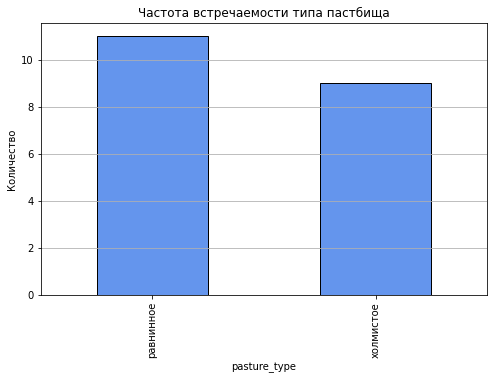

In [85]:
plot_value_counts(cow_buy, 'pasture_type', title = 'Частота встречаемости типа пастбища')

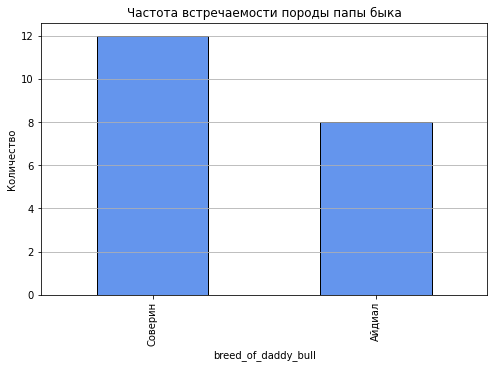

In [86]:
plot_value_counts(cow_buy, 'breed_of_daddy_bull', title = 'Частота встречаемости породы папы быка')

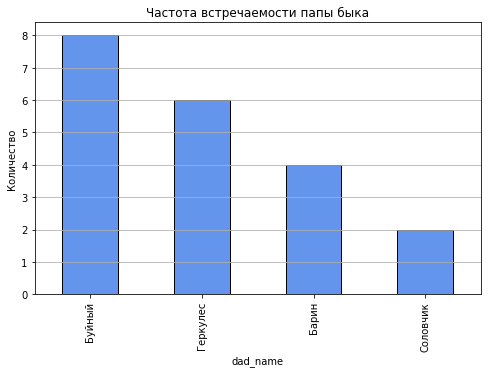

In [87]:
plot_value_counts(cow_buy, 'dad_name', title = 'Частота встречаемости папы быка')

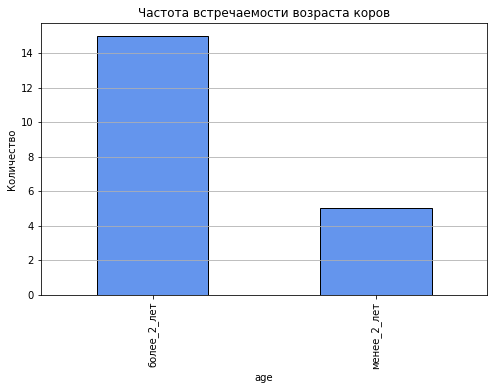

In [88]:
plot_value_counts(cow_buy, 'age', title = 'Частота встречаемости возраста коров')

Вывод: Увидели несколько выбросов в данных, обратили внимание, что есть некоторые странные значения, проверили некоторые теории. Можно улучшить данные, путём работы с выбросами.
Распределение в некоторых случаях нормальное, в некоторых случаях бимодальное.

## Корреляционный анализ данных

Цель: Изучим взаимосвязь между признаками, построим диаграммы рассеяния для количественных признаков, сделаем вывод.

### Построим матрицу корреляции

In [89]:
ferma_main_cleaned_without_id = ferma_main_cleaned.drop(columns='id')
correlation_matrix = ferma_main_cleaned_without_id.phik_matrix(interval_cols=['milk_kg',
                                                                   'feed_energy_unit',
                                                                   'crude_protein_g',
                                                                   'sugar_protein_ratio',
                                                                   'fat_content_percent',
                                                                   'protein_percent'])

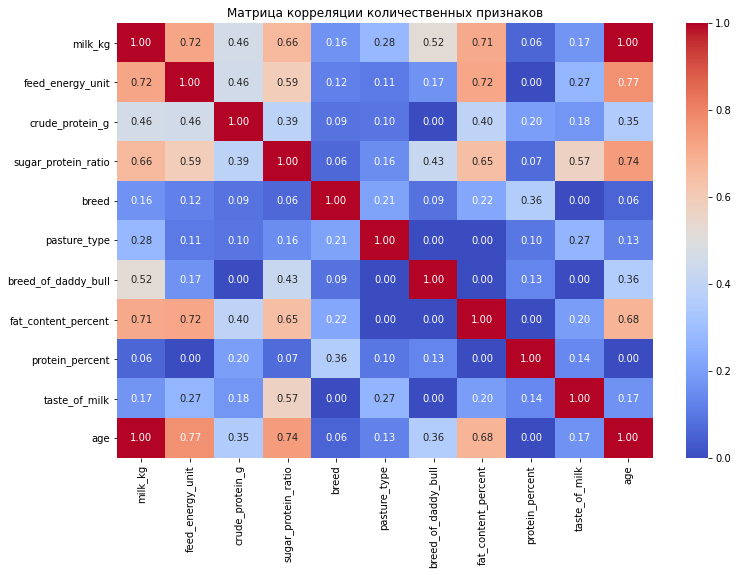

In [90]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции количественных признаков')
plt.show()

Максимальная корреляция между возрастом и удоем, также высока корреляция между удоем и энергетической ценностью.

### Диаграммы рассеяния

In [91]:
def scatter_plots_by_breed(df_numeric, df_categories, target='milk_kg', group='Порода'):

    df = df_numeric.join(df_categories[group])

    numeric_cols = df.select_dtypes(include='number').columns

    for col in numeric_cols:
        if col != target: 
            sns.scatterplot(x=df[col], y=df[target], hue=df[group], palette='Set2', alpha=0.7)
            plt.title(f'{target} vs {col} по {group}')
            plt.tight_layout()
            plt.show()

In [92]:
numerical_characteristics_cleaned = ferma_main_cleaned_without_id[[
    'milk_kg',
    'feed_energy_unit',
    'crude_protein_g',
    'sugar_protein_ratio',
    'fat_content_percent',
    'protein_percent']]

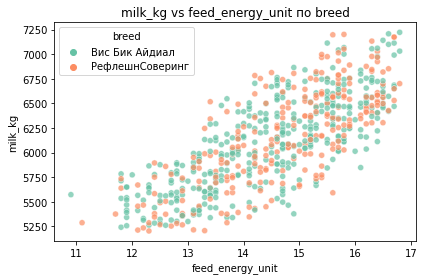

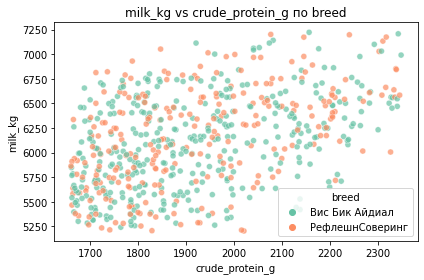

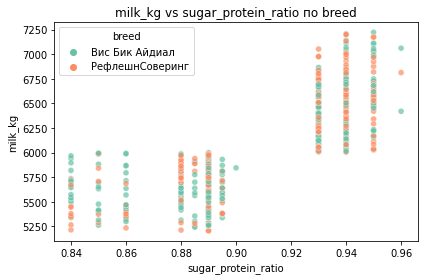

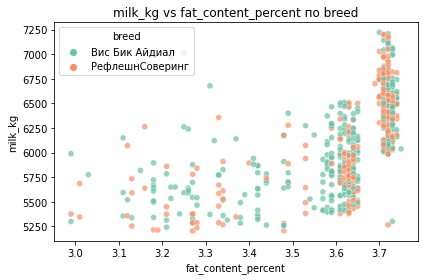

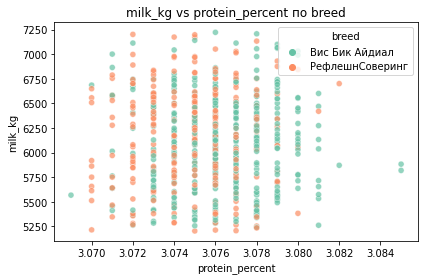

In [93]:
scatter_plots_by_breed(numerical_characteristics_cleaned, ferma_main_cleaned_without_id, target='milk_kg', group='breed')

1. Какая связь между кормом и количеством молока?
Между тем, сколько молока даёт корова, и тем, какой корм она ест, действительно есть связь. Вот что видно:

Больше энергии в корме — больше молока. Это самая понятная и стабильная закономерность. Энергия в корме — как топливо для коровы: если его больше, она работает лучше и даёт больше молока.

Соотношение сахара и белка в корме тоже важно. При хорошем балансе этих веществ коровы могут давать больше молока. Особенно это заметно у одной породы.

Просто белок (протеин) не так сильно влияет. Есть случаи, когда его много, а молока — мало. Значит, сам по себе он не решает.

Если в молоке больше жира или белка, то объём молока немного снижается. То есть либо молоко более жирное и питательное, либо его больше — но редко и то, и другое сразу.

2. Есть ли скрытые, неочевидные зависимости?
Да, есть:

Даже если у двух коров одинаковый корм, они могут давать разное количество молока.
Это значит, что есть и другие важные факторы: порода, возраст, здоровье, условия содержания.

В некоторых случаях, если значения кормовых показателей слишком высокие или слишком низкие, удой изменяется не просто по прямой, а по более сложной зависимости.

Поэтому:

Одних только показателей корма недостаточно — нужно добавлять другие данные (например, о самой корове).

Также стоит использовать модель, которая умеет замечать сложные и неочевидные зависимости.

3. Есть ли признаки, которые дублируют друг друга и могут мешать?
Такое бывает, когда два показателя слишком похожи. Тогда модель не понимает, кто из них важнее.

Но здесь:

По поведению разных признаков видно, что каждый даёт свою информацию.

Например, энергия в корме помогает, а жирность, наоборот, немного снижает удой — значит, они работают по-разному. 

Общий вывод по связи признаков с удоем молока:

Между удоем и некоторыми признаками наблюдаются нелинейные зависимости. Например, при росте жирности и белка в молоке удой немного снижается, но это происходит неравномерно — особенно заметно при жирности выше 3.4%. То же касается соотношения сахара к белку: при его увеличении удой в целом растёт, но у разных пород это происходит по-разному и неравномерно. Энергетическая ценность корма показывает почти линейную положительную зависимость, однако на высоких значениях заметен разброс, что тоже говорит о нелинейности. А вот содержание сырого протеина не даёт чёткой картины — связь очень слабая, и однозначного вывода о влиянии не сделать.

О мультиколлинеарности:

Сильной мультиколлинеарности между признаками не наблюдается. Каждый из них влияет на удой по-разному. Даже близкие по смыслу признаки, такие как жирность и белок, дают разные результаты. Производные признаки, вроде соотношения сахара к белку, также дают дополнительную информацию и не мешают другим. Это значит, что признаки не дублируют друг друга, и модель может использовать их все без риска запутаться.

## Обучение моделей линейной регрессии

Цель: Обучим три модели линейной регрессии. Для этого подготовим данные, обучим модели, оценим качество модели.

### Первая модель

In [94]:
X = ferma_main_cleaned.drop(columns = ['milk_kg'])
y = ferma_main_cleaned['milk_kg']

Определим какие признаки будем использовать для обучения:

Категориальные: Порода, Тип пастбища, Возраст

Количественные:
ЭКЕ, СПО, Жирность


Признаки Белок и Сырой протеин не быдем использовать из - за низкой корреляции между признаками.

In [95]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = RANDOM_STATE
)

In [96]:
cat_col_names = ['breed', 'age', 'breed_of_daddy_bull']
num_col_names = ['feed_energy_unit', 'sugar_protein_ratio', 'fat_content_percent']

In [97]:
# Кодирование категориальных
def preprocess_data(X_train, X_test, cat_col_names, num_col_names):
    # One-hot encoding
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names])

    encoder_col_names = encoder.get_feature_names_out(cat_col_names)
    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names, index=X_train.index)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names, index=X_test.index)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names, index=X_test.index)

    # Объединение
    X_train_final = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test_final = pd.concat([X_test_ohe, X_test_scaled], axis=1)

    return X_train_final, X_test_final

In [98]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return mse, mae, rmse

In [99]:
def calculate_prediction_interval(residuals):
    lower_quantile = np.percentile(residuals, 2.5)  
    upper_quantile = np.percentile(residuals, 97.5) 
    return lower_quantile, upper_quantile

построим график по количественным признакам тренировочного датасета:
гистограмму частотности распределения и ящик с усами.

R² на тестовой выборке: 0.7770009672336892


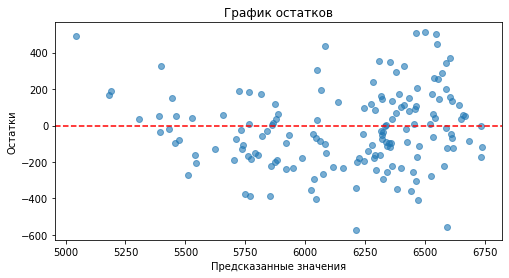

In [100]:
X_train_prepared, X_test_prepared = preprocess_data(X_train, X_test, cat_col_names, num_col_names)

# 2. Обучение модели
model_lr_1 = LinearRegression()
model_lr_1.fit(X_train_prepared, y_train)

# 3. Предсказания и метрика
predictions_1 = model_lr_1.predict(X_test_prepared)
r2_1 = r2_score(y_test, predictions_1)
print("R² на тестовой выборке:", r2_1)

# 4. График остатков
residuals_1 = y_test - predictions_1
plt.figure(figsize=(8, 4))
plt.scatter(predictions_1, residuals_1, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.show()

In [101]:
mse_1, mae_1, rmse_1 = calculate_metrics(y_test, predictions_1)

In [102]:
train_predictions_1 = model_lr_1.predict(X_train_prepared)
residuals_1_train = y_train - train_predictions_1

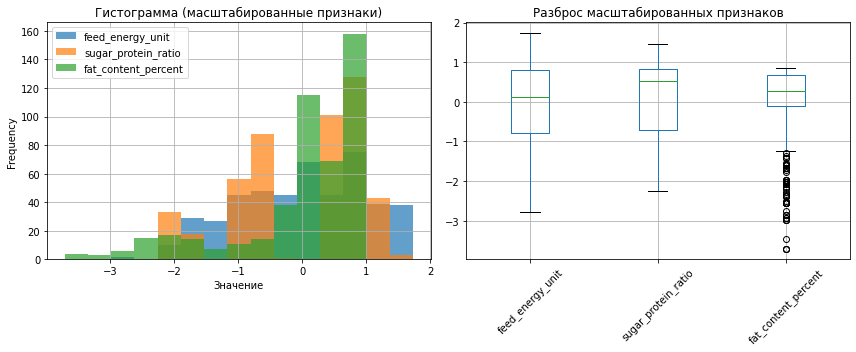

In [103]:
processed_num_features = [col for col in X_train_prepared.columns if col in num_col_names]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Гистограмма
X_train_prepared[processed_num_features].plot(kind='hist', bins=15, ax=axes[0], alpha=0.7)
axes[0].set_title('Гистограмма (масштабированные признаки)')
axes[0].set_xlabel('Значение')
axes[0].grid(True)

# Boxplot
X_train_prepared[processed_num_features].plot(kind='box', ax=axes[1])
axes[1].set_title('Разброс масштабированных признаков')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Вывод: Результат R² достаточно хороший, график остатков распределён равномерно. Паттернов не заметил. Можно попробовать улучшить данные разобравшись с выбросами.

### Обучим вторую модель линейной регрессии

Обучим модель с учетом неленейных связей.

In [104]:
X_train_mod = X_train.copy()
X_test_mod = X_test.copy()


spo_threshold = 0.92
X_train_mod['spo_high'] = (X_train_mod['sugar_protein_ratio'] > spo_threshold).astype(int)
X_test_mod['spo_high'] = (X_test_mod['sugar_protein_ratio'] > spo_threshold).astype(int)


X_train_mod['feed_energy_unit_sq'] = X_train_mod['feed_energy_unit'] ** 2
X_test_mod['feed_energy_unit_sq'] = X_test_mod['feed_energy_unit'] ** 2 

In [105]:
X_train_mod.head()

,id,feed_energy_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,breed_of_daddy_bull,fat_content_percent,protein_percent,taste_of_milk,age,spo_high,feed_energy_unit_sq
508,509,16.5,2123,0.94,РефлешнСоверинг,Холмистое,Соверин,3.70,3.074,вкусно,более_2_лет,1,272.25
383,384,12.5,1889,0.89,РефлешнСоверинг,Холмистое,Соверин,3.34,3.072,вкусно,менее_2_лет,0,156.25
587,588,14.7,1671,0.88,Вис Бик Айдиал,Равнинное,Айдиал,3.18,3.079,не вкусно,более_2_лет,0,216.09
197,198,14.4,2063,0.94,Вис Бик Айдиал,Холмистое,Айдиал,3.62,3.079,вкусно,более_2_лет,1,207.36
328,329,13.1,2077,0.89,Вис Бик Айдиал,Равнинное,Айдиал,3.64,3.076,вкусно,более_2_лет,0,171.61


R² на тестовой выборке: 0.8102530021806416


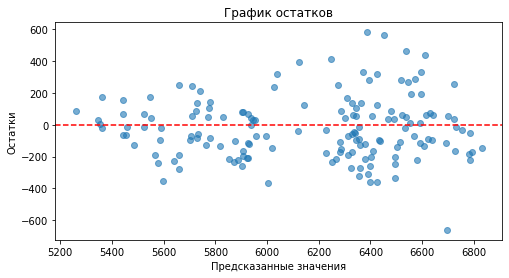

In [106]:
num_col_names = ['feed_energy_unit', 'sugar_protein_ratio', 'fat_content_percent', 'spo_high', 'feed_energy_unit_sq']  # Обновленный список числовых признаков

X_train_prepared, X_test_prepared = preprocess_data(X_train_mod, X_test_mod, cat_col_names, num_col_names)


model_lr_2 = LinearRegression()


model_lr_2.fit(X_train_prepared, y_train)


predictions_2 = model_lr_2.predict(X_test_prepared)


r2_2 = r2_score(y_test, predictions_2)
print("R² на тестовой выборке:", r2_2)


residuals_2 = y_test - predictions_2
plt.figure(figsize=(8, 4))
plt.scatter(predictions_2, residuals_2, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.show()

In [107]:
mse_2, mae_2, rmse_2 = calculate_metrics(y_test, predictions_2)

In [108]:
train_predictions_2 = model_lr_2.predict(X_train_prepared)
residuals_2_train = y_train - train_predictions_2

Вывод: Качетсво модели улучшилось, так как значение R² стало ближе к 1.

### Третья модель

Добавим признак "имя папы" из файла ferma_dad.csv и посмотрим, как он скажется на модели.

Объединим датасеты

In [109]:

data = pd.merge(ferma_main_cleaned, ferma_dad, on='id', how='left')

data.head()


,id,milk_kg,feed_energy_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,breed_of_daddy_bull,fat_content_percent,protein_percent,taste_of_milk,age,dad_name
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,Буйный
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,Барин


In [110]:
spo_threshold = 0.92
data['spo_high'] = (data['sugar_protein_ratio'] > spo_threshold).astype(int)

data['feed_energy_unit_sq'] = data['feed_energy_unit'] ** 2

R² на тестовой выборке: 0.8219613784304447


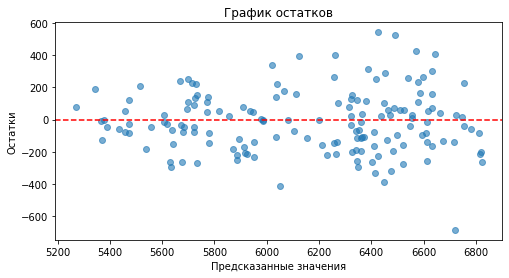

In [111]:

X = data.drop(columns=['milk_kg', 'id'])  # 'target' - целевая переменная
y = data['milk_kg']


cat_col_names = ['breed', 'age', 'breed_of_daddy_bull', 'dad_name']  # 'father_name' добавлен как категориальный признак
num_col_names = ['feed_energy_unit', 'sugar_protein_ratio', 'fat_content_percent', 'spo_high', 'feed_energy_unit_sq']


X_train, X_test = train_test_split(X, random_state=42)

X_train_prepared, X_test_prepared = preprocess_data(X_train, X_test, cat_col_names, num_col_names)


model_lr_3 = LinearRegression()


model_lr_3.fit(X_train_prepared, y_train)


predictions_3 = model_lr_3.predict(X_test_prepared)


r2_3 = r2_score(y_test, predictions_3)
print("R² на тестовой выборке:", r2_3)


residuals_3 = y_test - predictions_3
plt.figure(figsize=(8, 4))
plt.scatter(predictions_3, residuals_3, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.show()


In [112]:
mse_3, mae_3, rmse_3 = calculate_metrics(y_test, predictions_3)

In [113]:
train_predictions_3 = model_lr_3.predict(X_train_prepared)
residuals_3_train = y_train - train_predictions_3

Вывод: Модель показала не плохой результат.

### Сравним результаты моделей

In [114]:
print(f'Лучшее значение R²: ', r2_2, ' у второй модели')
print(f'Второе значение R²: ', r2_3, ' у третьей модели')
print(f'Минимальное значение R²: ', r2_1, ' у первой модели')

Лучшее значение R²:  0.8102530021806416  у второй модели
Второе значение R²:  0.8219613784304447  у третьей модели
Минимальное значение R²:  0.7770009672336892  у первой модели


In [115]:
print(f"Модель 1: MSE={mse_1}, MAE={mae_1}, RMSE={rmse_1}")
print(f"Модель 2: MSE={mse_2}, MAE={mae_2}, RMSE={rmse_2}")
print(f"Модель 3: MSE={mse_3}, MAE={mae_3}, RMSE={rmse_3}")

Модель 1: MSE=45394.79018896575, MAE=170.50948448208223, RMSE=213.06053174852858
Модель 2: MSE=38625.840875383336, MAE=155.6530327512868, RMSE=196.53457933753882
Модель 3: MSE=36242.42567972076, MAE=149.67462400565586, RMSE=190.37443546789774


In [116]:
interval_1 = calculate_prediction_interval(residuals_1_train)
interval_2 = calculate_prediction_interval(residuals_2_train)
interval_3 = calculate_prediction_interval(residuals_3_train)

In [117]:
print(f"Доверительный интервал для модели 1: {interval_1}")
print(f"Доверительный интервал для модели 2: {interval_2}")
print(f"Доверительный интервал для модели 3: {interval_3}")

Доверительный интервал для модели 1: (-392.0332170413826, 459.0303419951672)
Доверительный интервал для модели 2: (-355.7947811987942, 406.1021651951687)
Доверительный интервал для модели 3: (-329.1774698611016, 392.14269332037725)


Исходя из метрик, можно сделать вывод, что модель 3 лучше остальных.

### Спрогнозируем удой коров с помощью лучшей модели

In [118]:
mean_values = ferma_main_cleaned[['feed_energy_unit', 'crude_protein_g', 'sugar_protein_ratio']].mean()


mean_values = mean_values * 1.05
mean_values

feed_energy_unit         15.276162
crude_protein_g        2019.947532
sugar_protein_ratio       0.958744
dtype: float64

In [119]:
cow_buy['feed_energy_unit'] = mean_values['feed_energy_unit']
cow_buy['crude_protein_g'] = mean_values['crude_protein_g']
cow_buy['sugar_protein_ratio'] = mean_values['sugar_protein_ratio']


cow_buy.head()

,breed,pasture_type,breed_of_daddy_bull,dad_name,fat_content_percent,current_protein_level_percent,age,feed_energy_unit,crude_protein_g,sugar_protein_ratio
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,0.958744
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,0.958744
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,2019.947532,0.958744
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,0.958744
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,0.958744


In [120]:
spo_threshold = 0.92
cow_buy['spo_high'] = (cow_buy['sugar_protein_ratio'] > spo_threshold).astype(int)


cow_buy['feed_energy_unit_sq'] = cow_buy['feed_energy_unit'] ** 2

In [121]:
cat_col_names = ['breed', 'age', 'breed_of_daddy_bull', 'dad_name']  # 'dad_name' добавлен как категориальный признак
num_col_names = ['feed_energy_unit', 'sugar_protein_ratio', 'fat_content_percent', 'spo_high', 'feed_energy_unit_sq']

In [122]:
X_cow_buy = cow_buy[cat_col_names + num_col_names]

X_cow_buy_preprocessed, _ = preprocess_data(X_cow_buy, X_cow_buy, cat_col_names, num_col_names)

print(X_cow_buy_preprocessed.head())
X_cow_buy = cow_buy[cat_col_names + num_col_names]

X_cow_buy_preprocessed, _ = preprocess_data(X_cow_buy, X_cow_buy, cat_col_names, num_col_names)

X_cow_buy_preprocessed.head()


   breed_РефлешнСоверинг  age_менее_2_лет  breed_of_daddy_bull_Соверин  \
0                    0.0              0.0                          0.0   
1                    0.0              1.0                          1.0   
2                    1.0              0.0                          1.0   
3                    1.0              0.0                          0.0   
4                    1.0              0.0                          0.0   

   dad_name_Буйный  dad_name_Геркулес  dad_name_Соловчик  feed_energy_unit  \
0              0.0                1.0                0.0      1.776357e-15   
1              1.0                0.0                0.0      1.776357e-15   
2              0.0                0.0                0.0      1.776357e-15   
3              1.0                0.0                0.0      1.776357e-15   
4              1.0                0.0                0.0      1.776357e-15   

   sugar_protein_ratio  fat_content_percent  spo_high  feed_energy_unit_sq  
0        

,breed_РефлешнСоверинг,age_менее_2_лет,breed_of_daddy_bull_Соверин,dad_name_Буйный,dad_name_Геркулес,dad_name_Соловчик,feed_energy_unit,sugar_protein_ratio,fat_content_percent,spo_high,feed_energy_unit_sq
0,0.0,0.0,0.0,0.0,1.0,0.0,1.776357e-15,-1.110223e-16,0.020225,0.0,0.0
1,0.0,1.0,1.0,1.0,0.0,0.0,1.776357e-15,-1.110223e-16,-0.303380,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,0.0,1.776357e-15,-1.110223e-16,0.101127,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.776357e-15,-1.110223e-16,-1.436000,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.776357e-15,-1.110223e-16,0.505634,0.0,0.0


In [123]:

predictions_cow_buy = model_lr_3.predict(X_cow_buy_preprocessed)


cow_buy['predicted_milk_yield'] = predictions_cow_buy


cow_buy[['predicted_milk_yield']]

,predicted_milk_yield
0,6307.412280
1,6065.119796
2,6056.881371
3,6248.868650
4,6344.226858
5,6110.489582
6,6307.412280
7,6310.371973
8,6056.881371
9,6015.536249


Вывод: Выбрали лучшую модель, прогнали данные через неё, получили предсказания для каждой коровы в списке.

## Обучим модель классификации для определения вкуса молока

Цель: Обучить модлеь на данных ferma_main, которая предскажет, понравится ли молоко фермеру или нет.

In [124]:
X = ferma_main_cleaned.drop(columns = ['taste_of_milk'])
y = ferma_main_cleaned['taste_of_milk'].apply(lambda x: 1 if x == 'вкусно' else 0)

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = RANDOM_STATE
)

In [125]:
cat_col_names = ['breed', 'age', 'breed_of_daddy_bull']
num_col_names = ['feed_energy_unit', 'sugar_protein_ratio', 'fat_content_percent', 'crude_protein_g', 'protein_percent']

In [126]:

encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[cat_col_names])
X_test_cat = encoder.transform(X_test[cat_col_names])


scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_col_names])
X_test_num = scaler.transform(X_test[num_col_names])

X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoder.get_feature_names_out(cat_col_names), index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoder.get_feature_names_out(cat_col_names), index=X_test.index)

X_train_num_df = pd.DataFrame(X_train_num, columns=num_col_names, index=X_train.index)
X_test_num_df = pd.DataFrame(X_test_num, columns=num_col_names, index=X_test.index)

# Объединение
X_train_final = pd.concat([X_train_cat_df, X_train_num_df], axis=1)
X_test_final = pd.concat([X_test_cat_df, X_test_num_df], axis=1)

In [127]:
model_logreg = LogisticRegression()
model_logreg.fit(X_train_final, y_train)

LogisticRegression()

In [128]:
y_pred = model_logreg.predict(X_test_final)

In [129]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, pos_label=1)
precision = precision_score(y_test, y_pred, pos_label=1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"Precision:{precision:.4f}")

Accuracy: 0.5987
Recall:   0.8409
Precision:0.6016


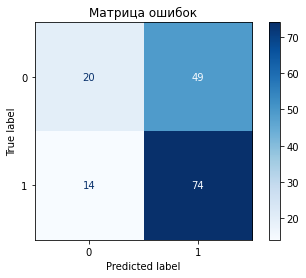

In [130]:
cm = confusion_matrix(y_test, y_pred, labels=model_logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_logreg.classes_)
disp.plot(cmap='Blues')
plt.title("Матрица ошибок")
plt.show()

Ошибка первого рода гораздо критичнее, гораздо хуже купить корову и пожалеть, чем пропустить хорошую корову.

In [131]:
y_proba = model_logreg.predict_proba(X_test_final)[:, list(model_logreg.classes_).index(1)]

thresholds = [round(i, 2) for i in np.linspace(0.5, 1, 10)]
results = []


for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)  
    prec = precision_score(y_test, y_pred_thresh, zero_division=0) 
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)  
    results.append({'Порог': t, 'Precision': prec, 'Recall': rec})


df_results = pd.DataFrame(results)


df_results[df_results['Precision'] == df_results['Precision'].max()]

,Порог,Precision,Recall
4,0.72,0.730769,0.215909


Accuracy: 0.5159
Recall:   0.2159
Precision:0.7308


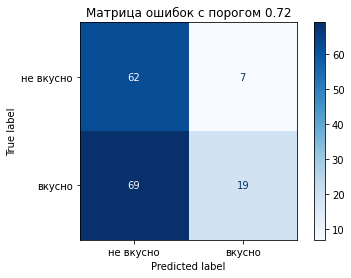

In [132]:
y_proba = model_logreg.predict_proba(X_test_final)[:, 1]


threshold = 0.72
y_pred = (y_proba >= threshold).astype(int)  


y_pred_str = ['вкусно' if pred == 1 else 'не вкусно' for pred in y_pred]


accuracy = accuracy_score(y_test, y_pred)  
recall = recall_score(y_test, y_pred)  
precision = precision_score(y_test, y_pred)  


print(f"Accuracy: {accuracy:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"Precision:{precision:.4f}")


cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['не вкусно', 'вкусно'])
disp.plot(cmap='Blues')
plt.title("Матрица ошибок с порогом 0.72")
plt.show()


Для сведения количества ошибок первого рода к нулю, приняли пороговое значение 0.72

In [133]:
cow_buy = cow_buy.rename(columns = {'current_protein_level_percent': 'protein_percent'})

In [134]:
cat_col_names = ['breed', 'age', 'breed_of_daddy_bull']
num_col_names = ['feed_energy_unit', 'sugar_protein_ratio', 'fat_content_percent', 'crude_protein_g', 'protein_percent',]

X_cow_buy_ohe = encoder.transform(cow_buy[cat_col_names])
X_cow_buy_ohe = pd.DataFrame(
    X_cow_buy_ohe, 
    columns=encoder.get_feature_names_out(cat_col_names), 
    index=cow_buy.index
)


X_cow_buy_scaled = scaler.transform(cow_buy[num_col_names])
X_cow_buy_scaled = pd.DataFrame(
    X_cow_buy_scaled, 
    columns=num_col_names, 
    index=cow_buy.index
)


X_cow_buy_final = pd.concat([X_cow_buy_ohe, X_cow_buy_scaled], axis=1)

# Прогноз
y_proba_cow_buy = model_logreg.predict_proba(X_cow_buy_final)[:, 1]
y_pred_cow_buy = (y_proba_cow_buy >= 0.72).astype(int)
y_pred_cow_buy_str = ['вкусно' if pred == 1 else 'не вкусно' for pred in y_pred_cow_buy]

cow_buy['predicted_taste'] = y_pred_cow_buy_str

print(cow_buy[['breed', 'age', 'predicted_taste']])

              breed          age predicted_taste
0    Вис Бик Айдиал  более_2_лет       не вкусно
1    Вис Бик Айдиал  менее_2_лет          вкусно
2   РефлешнСоверинг  более_2_лет          вкусно
3   РефлешнСоверинг  более_2_лет       не вкусно
4   РефлешнСоверинг  более_2_лет       не вкусно
5   РефлешнСоверинг  менее_2_лет       не вкусно
6    Вис Бик Айдиал  более_2_лет       не вкусно
7    Вис Бик Айдиал  более_2_лет          вкусно
8   РефлешнСоверинг  более_2_лет          вкусно
9   РефлешнСоверинг  менее_2_лет          вкусно
10   Вис Бик Айдиал  более_2_лет       не вкусно
11  РефлешнСоверинг  более_2_лет       не вкусно
12   Вис Бик Айдиал  более_2_лет       не вкусно
13   Вис Бик Айдиал  менее_2_лет       не вкусно
14  РефлешнСоверинг  более_2_лет          вкусно
15  РефлешнСоверинг  более_2_лет       не вкусно
16   Вис Бик Айдиал  более_2_лет          вкусно
17  РефлешнСоверинг  менее_2_лет       не вкусно
18   Вис Бик Айдиал  более_2_лет       не вкусно
19  РефлешнСоверинг 

## Вывод

Проверим, какие коровы соответствуют нашим условиям:

In [135]:
cow_buy_recomended = cow_buy.query('predicted_taste == "вкусно" & predicted_milk_yield > 6000')
cow_buy_recomended

,breed,pasture_type,breed_of_daddy_bull,dad_name,fat_content_percent,protein_percent,age,feed_energy_unit,crude_protein_g,sugar_protein_ratio,spo_high,feed_energy_unit_sq,predicted_milk_yield,predicted_taste
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,0.958744,1,233.361138,6065.119796,вкусно
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,2019.947532,0.958744,1,233.361138,6056.881371,вкусно
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,0.958744,1,233.361138,6310.371973,вкусно
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,2019.947532,0.958744,1,233.361138,6056.881371,вкусно
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,15.276162,2019.947532,0.958744,1,233.361138,6015.536249,вкусно
14,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,2019.947532,0.958744,1,233.361138,6056.881371,вкусно
16,Вис Бик Айдиал,холмистое,Соверин,Соловчик,3.73,3.079,более_2_лет,15.276162,2019.947532,0.958744,1,233.361138,6129.289750,вкусно


In [136]:
len(cow_buy_recomended)

7

Таких коров 7 штук.

В этом проекте мы работали с двумя типами моделей: линейной регрессией и логистической регрессией, с целью помочь фермеру выбрать коров с вкусным молоком.
Линейная регрессия
Эта модель использовалась для предсказания количественных характеристик молока. В базовой версии она работала не очень точно. Чтобы улучшить качество, мы:

добавили новый бинарный признак spo_high, который показывает, хорошее ли соотношение сахара и белка в корме;

добавили дополнительный признак — квадрат энергетической ценности корма (feed_energy_unit_sq);

упростили модель, убрав лишние категориальные признаки.

После этих доработок модель стала работать заметно лучше.

Логистическая регрессия
Эта модель помогала ответить на главный вопрос: будет ли молоко вкусным или нет.

Мы подготовили данные: закодировали категории, масштабировали числа. На базовом пороге (0.5) модель часто ошибалась — предсказывала "вкусно", когда это не так. А фермеру важно не ошибиться с выбором — ведь корову потом не вернуть.

Поэтому мы изменили порог срабатывания модели. 
Коров с вкусным молоком оказалось 7 штук.

Мы смотрели на точность (precision) и полноту (recall).

В этой задаче важнее точность — чтобы не ошибаться и не покупать корову с невкусным молоком.

Также строили матрицу ошибок, чтобы видеть, какие ошибки делает модель.

При выборе коровы к покупке, я бы рекомендовал брать молодых коров, в молоке которых большой уровень жирности.